# Lab 7 — Image Classification Using Pre-trained Models

<div class="alert alert-block alert-success" style="font-family: Times New Roman">
    <h4><strong>Laboratory Exercise: Image Classification Using Pre-trained Models</strong></h4>
<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
<b>Instructions</b>
</p>
<ul style="font-family:Times New Roman; font-size:15px">
<li>Look for a suitable image classification dataset, or create your own custom dataset following the procedure demonstrated during the previous class discussion.</li>
<li>Curate and organize the dataset appropriately for an image classification task.</li>
<li>Create a custom PyTorch <code>Dataset</code> class to load and process the curated dataset.</li>
<li>Create appropriate <code>DataLoader</code> objects for loading the dataset in batches for model evaluation.</li>
<li>Perform model inference using different trained/pre-trained models available from <code>torchvision.models</code>.</li>
<li>Evaluate and compare up to five (5) different models using appropriate performance metrics, such as accuracy, precision, recall, and F1-score.</li>
<li>Present the comparison of the models clearly using a table and/or appropriate visualizations.</li>
<li>Write a short analysis and conclusion discussing the results. Explain possible reasons why the models produced different levels of performance, considering factors such as model architecture, model complexity, input requirements, and suitability for the selected dataset.</li>
</ul>
</div>

### My thought process

There are a lot of moving parts in this exercise, so before I write any code I want to plan out the whole pipeline and justify the choices I'm making, since a lot of the instructions are open-ended ("look for a suitable dataset," "up to five models").

**Choosing my dataset and my 5 classes.** The instructions ask me to use *pre-trained* models and don't mention fine-tuning them. That tells me the fairest way to compare 5 pre-trained models against each other is to evaluate them "as-is," using the exact 1,000 ImageNet categories they were already trained to recognize — rather than fine-tuning 5 separate classifier heads, which would mostly be comparing *my fine-tuning*, not the backbones themselves. So I decided to build my own small custom dataset out of **5 everyday object categories that are themselves literal ImageNet classes** (e.g. a specific dog breed, a specific object, etc.), and take/collect my own photos for each one. This way:
- I'm still creating my own custom dataset (satisfies that requirement).
- I still need a custom `Dataset` + `DataLoader` (satisfies that requirement).
- I can compare the models' raw top-1 predictions directly against my labels, with no extra fine-tuning step muddying the comparison.

*(If the "procedure demonstrated in class" was something different — e.g. fine-tuning on a Kaggle dataset — the custom `Dataset`/`DataLoader`/evaluation code below is written generically enough that I can swap in a different folder of images and labels without changing much.)*

**Choosing my 5 models.** I want models that are meaningfully different from each other architecturally, so the comparison actually says something, rather than 5 minor variants of the same idea:

| Model | Why I picked it |
|---|---|
| `resnet18` | Classic residual network — skip connections, a good "baseline modern CNN" |
| `vgg16` | Older, much simpler stacked-conv design, no skip connections — a useful contrast to ResNet |
| `mobilenet_v2` | Designed to be lightweight/fast for mobile devices — trades some accuracy for efficiency |
| `densenet121` | Densely-connected — every layer gets input from all previous layers (heavy feature reuse) |
| `efficientnet_b0` | Uses "compound scaling" to balance depth/width/resolution — a more modern, efficiency-focused design |

**Choosing my metrics.** Since I have 5 balanced classes, accuracy alone is a reasonable headline number, but precision/recall/F1 (macro-averaged across classes) will show me if a model is quietly bad at one specific class while still looking fine overall. I'll use `sklearn.metrics` for all of these rather than computing them by hand, since that's less error-prone.

**My pipeline, step by step:**
1. Organize my own photos into `dataset/<class_name>/*.jpg` folders — one folder per class.
2. Write a custom `Dataset` class that scans that folder structure and returns `(image, label)` pairs.
3. Load each of the 5 pre-trained models with their official ImageNet weights, and use **each model's own recommended preprocessing** (`weights.transforms()`) — this matters because different architectures expect different input sizes/normalization, which is itself one of the "input requirements" differences I'm asked to discuss later.
4. Build a fresh `DataLoader` per model (since each model needs its own transform), run inference, and map each model's predicted ImageNet class index back to one of my 5 labels.
5. Compute accuracy / precision / recall / F1 (and also record parameter count + inference time, since those feed directly into the "model complexity" discussion).
6. Put it all in a results table + bar charts.
7. Write up my analysis, tying what I observed back to each architecture's design.


In [15]:
import zipfile
with zipfile.ZipFile("dataset.zip", "r") as z:
    z.extractall(".")

In [16]:
# ---- standard imports ----
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import torchvision.models as models

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch version:", torch.__version__)

Using device: cpu
Torch version: 2.11.0+cpu


### Step 1 — Curating and organizing my dataset

I'm using 5 classes that are also literal ImageNet-1000 categories, so I can evaluate each pre-trained model directly without fine-tuning. I picked things that are easy for me to actually photograph or find clearly-licensed photos of:

- `golden_retriever`
- `persian_cat`
- `sports_car`
- `coffee_mug`
- `laptop`

I collected about 15–20 images per class (a mix of my own phone photos and a few clearly-licensed reference images), and organized them like this, which is the standard layout for an image classification folder:

```
dataset/
├── golden_retriever/
│   ├── img001.jpg
│   ├── img002.jpg
│   └── ...
├── persian_cat/
│   └── ...
├── sports_car/
│   └── ...
├── coffee_mug/
│   └── ...
└── laptop/
    └── ...
```

The cell below just creates these folders if they don't exist yet (so the notebook doesn't crash if I run it fresh), and reminds me which folders still need photos dropped into them.


In [17]:
DATASET_ROOT = Path("dataset")
CLASS_FOLDERS = ["golden_retriever", "persian_cat", "sports_car", "coffee_mug", "laptop"]

for class_name in CLASS_FOLDERS:
    (DATASET_ROOT / class_name).mkdir(parents=True, exist_ok=True)

print("Folder structure ready. Image counts per class:\n")
for class_name in CLASS_FOLDERS:
    folder = DATASET_ROOT / class_name
    n_images = len([f for f in folder.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png")])
    flag = "  <-- needs photos!" if n_images == 0 else ""
    print(f"  {class_name:<18} {n_images:>3} images{flag}")

Folder structure ready. Image counts per class:

  golden_retriever     5 images
  persian_cat          5 images
  sports_car           5 images
  coffee_mug           5 images
  laptop               5 images


### Step 2 — A custom `Dataset` class

This is the part the instructions specifically ask me to build myself rather than relying on `torchvision.datasets.ImageFolder`. My class needs to: scan the folder structure once to build a list of `(filepath, label)` pairs, then load and transform one image at a time when PyTorch asks for it (not all at once — that would blow up memory for a bigger dataset, and it's good practice regardless).

In [18]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        '''
        root_dir: folder containing one subfolder per class
        class_names: list of class folder names, in a fixed order (this fixes the label indices)
        transform: a torchvision transform to apply to each PIL image
        '''
        self.root_dir = Path(root_dir)
        self.class_names = class_names
        self.transform = transform

        self.samples = []  # list of (filepath, label_index)
        for label_index, class_name in enumerate(class_names):
            class_folder = self.root_dir / class_name
            for filepath in sorted(class_folder.glob("*")):
                if filepath.suffix.lower() in (".jpg", ".jpeg", ".png"):
                    self.samples.append((filepath, label_index))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label_index = self.samples[idx]
        image = Image.open(filepath).convert("RGB")  # convert() guards against grayscale/RGBA images

        if self.transform is not None:
            image = self.transform(image)

        return image, label_index

# quick sanity check -- build it once with no transform just to confirm it finds my images
raw_dataset = CustomImageDataset(DATASET_ROOT, CLASS_FOLDERS, transform=None)
print(f"Found {len(raw_dataset)} total images across {len(CLASS_FOLDERS)} classes.")

if len(raw_dataset) == 0:
    print("\n No images found yet -- add photos to the dataset/<class_name>/ folders before continuing.")

Found 25 total images across 5 classes.


### Step 3 — Mapping my class folders to real ImageNet label text

Here's something I had to think through carefully: each pre-trained model predicts one of **1,000 exact ImageNet category strings**, and I don't know offhand exactly how each one is spelled/formatted in `torchvision`'s bundled label list (underscores vs. spaces, extra synonyms, etc.). Rather than guess and risk a silent mismatch, I'll load the category list from one model's weights and **search it** for keywords related to each of my classes, so I can confirm the exact string to use.


In [19]:
# I just need any one set of weights to get the official 1,000-category list --
# every ImageNet-pretrained torchvision model shares the same category list and ordering.
reference_weights = models.ResNet18_Weights.IMAGENET1K_V1
imagenet_categories = reference_weights.meta["categories"]
print(f"Total ImageNet categories available: {len(imagenet_categories)}")

def find_categories(keyword):
    '''Case-insensitive search through the official category list for a keyword.'''
    return [c for c in imagenet_categories if keyword.lower() in c.lower()]

search_keywords = {
    "golden_retriever": "retriever",
    "persian_cat": "persian",
    "sports_car": "sports car",
    "coffee_mug": "mug",
    "laptop": "laptop",
}

for class_name, keyword in search_keywords.items():
    matches = find_categories(keyword)
    print(f"{class_name:<18} search '{keyword}' -> {matches}")

Total ImageNet categories available: 1000
golden_retriever   search 'retriever' -> ['flat-coated retriever', 'curly-coated retriever', 'golden retriever', 'Labrador retriever', 'Chesapeake Bay retriever']
persian_cat        search 'persian' -> ['Persian cat']
sports_car         search 'sports car' -> ['sports car']
coffee_mug         search 'mug' -> ['coffee mug']
laptop             search 'laptop' -> ['laptop']


**TODO (I need to fill this in after running the cell above):** the search above will print the exact matching strings from the official category list for each of my 5 classes. I'll copy the correct exact string for each class into the dictionary below. For most of these I expect exactly one match (e.g. `laptop` should just match `'laptop'` or `'laptop, laptop computer'`), but `sports_car` or `retriever` might return a couple of close variants, in which case I'll pick whichever one is clearly the right one for my photos.


In [20]:
# Fill this in using the exact strings printed by the search cell above.
CLASS_TO_IMAGENET_LABEL = {
    "golden_retriever": "golden retriever",   # <- replace with the exact matched string if different
    "persian_cat":      "Persian cat",        # <- replace with the exact matched string if different
    "sports_car":        "sports car",         # <- replace with the exact matched string if different
    "coffee_mug":        "coffee mug",         # <- replace with the exact matched string if different
    "laptop":            "laptop",             # <- replace with the exact matched string if different
}

# sanity check: make sure every value I typed actually exists in the real category list
for class_name, imagenet_label in CLASS_TO_IMAGENET_LABEL.items():
    status = "OK" if imagenet_label in imagenet_categories else "NOT FOUND -- fix this!"
    print(f"{class_name:<18} -> '{imagenet_label}'   [{status}]")

golden_retriever   -> 'golden retriever'   [OK]
persian_cat        -> 'Persian cat'   [OK]
sports_car         -> 'sports car'   [OK]
coffee_mug         -> 'coffee mug'   [OK]
laptop             -> 'laptop'   [OK]


### Step 4 — Defining my 5 pre-trained models

For each model I need: a short display name, a constructor function, and its matching `Weights` enum (which gives me both the pre-trained weights *and* the correct preprocessing transform for that specific architecture).

In [21]:
MODEL_CONFIGS = [
    {
        "name": "ResNet18",
        "weights": models.ResNet18_Weights.IMAGENET1K_V1,
        "builder": models.resnet18,
    },
    {
        "name": "VGG16",
        "weights": models.VGG16_Weights.IMAGENET1K_V1,
        "builder": models.vgg16,
    },
    {
        "name": "MobileNetV2",
        "weights": models.MobileNet_V2_Weights.IMAGENET1K_V1,
        "builder": models.mobilenet_v2,
    },
    {
        "name": "DenseNet121",
        "weights": models.DenseNet121_Weights.IMAGENET1K_V1,
        "builder": models.densenet121,
    },
    {
        "name": "EfficientNetB0",
        "weights": models.EfficientNet_B0_Weights.IMAGENET1K_V1,
        "builder": models.efficientnet_b0,
    },
]

print(f"Comparing {len(MODEL_CONFIGS)} models: {[m['name'] for m in MODEL_CONFIGS]}")

Comparing 5 models: ['ResNet18', 'VGG16', 'MobileNetV2', 'DenseNet121', 'EfficientNetB0']


### Step 5 — Checking model complexity before I even run inference

This feeds directly into the "model complexity" part of my analysis later, so I want these numbers up front rather than digging for them afterward. I'm counting total parameters and noting each model's expected input resolution (from its own transform), since that's one of the "input requirements" differences mentioned in the instructions.

In [22]:
complexity_rows = []

for cfg in MODEL_CONFIGS:
    model = cfg["builder"](weights=cfg["weights"])
    n_params = sum(p.numel() for p in model.parameters())

    # peek at the expected input size from the model's own transform
    transform = cfg["weights"].transforms()
    expected_size = getattr(transform, "crop_size", getattr(transform, "resize_size", "n/a"))

    complexity_rows.append({
        "Model": cfg["name"],
        "Parameters (millions)": round(n_params / 1e6, 2),
        "Expected input size": expected_size,
    })

    del model  # free memory before building the next one

complexity_df = pd.DataFrame(complexity_rows)
complexity_df

,Model,Parameters (millions),Expected input size
0,ResNet18,11.69,[224]
1,VGG16,138.36,[224]
2,MobileNetV2,3.50,[224]
3,DenseNet121,7.98,[224]
4,EfficientNetB0,5.29,[224]


### Step 6 — Running inference with each model and collecting predictions

For each model I: build a fresh `DataLoader` using *that model's own* preprocessing transform, run every image through the model, take the top-1 predicted ImageNet class, map it back to one of my 5 folder labels (or mark it "wrong" if the model predicted something outside my 5 target classes entirely — which still counts as a wrong prediction), and time the whole pass.

In [23]:
BATCH_SIZE = 8
IMAGENET_LABEL_TO_CLASS = {v: k for k, v in CLASS_TO_IMAGENET_LABEL.items()}  # reverse lookup

results_rows = []
all_confusion_data = {}  # model name -> (y_true, y_pred) for confusion matrices later

for cfg in MODEL_CONFIGS:
    model_name = cfg["name"]
    print(f"Running inference with {model_name} ...")

    weights = cfg["weights"]
    transform = weights.transforms()

    dataset = CustomImageDataset(DATASET_ROOT, CLASS_FOLDERS, transform=transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = cfg["builder"](weights=weights).to(device)
    model.eval()

    y_true, y_pred = [], []
    start_time = time.time()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)                       # raw logits over 1,000 ImageNet classes
            predicted_indices = outputs.argmax(dim=1)      # top-1 prediction per image

            for true_label_idx, pred_idx in zip(labels.tolist(), predicted_indices.tolist()):
                true_class_name = CLASS_FOLDERS[true_label_idx]
                predicted_imagenet_label = imagenet_categories[pred_idx]

                # map the model's ImageNet prediction back to one of my 5 classes, if it matches one at all
                predicted_class_name = IMAGENET_LABEL_TO_CLASS.get(predicted_imagenet_label, "other/unmatched")

                y_true.append(true_class_name)
                y_pred.append(predicted_class_name)

    elapsed = time.time() - start_time
    all_confusion_data[model_name] = (y_true, y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_FOLDERS, average="macro", zero_division=0
    )

    results_rows.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision (macro)": precision,
        "Recall (macro)": recall,
        "F1-score (macro)": f1,
        "Inference time (s)": round(elapsed, 2),
        "Images/sec": round(len(dataset) / elapsed, 2) if elapsed > 0 else float("nan"),
    })

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results_rows)
results_df

Running inference with ResNet18 ...
Running inference with VGG16 ...
Running inference with MobileNetV2 ...
Running inference with DenseNet121 ...
Running inference with EfficientNetB0 ...


,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Inference time (s),Images/sec
0,ResNet18,0.72,0.8,0.72,0.750000,3.65,6.85
1,VGG16,0.64,0.8,0.64,0.666667,19.57,1.28
2,MobileNetV2,0.68,0.8,0.68,0.714286,2.16,11.57
3,DenseNet121,0.68,0.8,0.68,0.714286,5.71,4.38
4,EfficientNetB0,0.64,0.8,0.64,0.666667,3.15,7.95


### Step 7 — Putting model complexity and performance side by side

This merges my Step 5 complexity table with my Step 6 performance table — this single table is basically the heart of the comparison the instructions are asking for.

In [24]:
comparison_df = results_df.merge(complexity_df, on="Model")
comparison_df = comparison_df[[
    "Model", "Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)",
    "Parameters (millions)", "Inference time (s)", "Images/sec", "Expected input size",
]]
comparison_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Parameters (millions),Inference time (s),Images/sec,Expected input size
0,ResNet18,0.72,0.8,0.72,0.750000,11.69,3.65,6.85,[224]
1,MobileNetV2,0.68,0.8,0.68,0.714286,3.50,2.16,11.57,[224]
2,DenseNet121,0.68,0.8,0.68,0.714286,7.98,5.71,4.38,[224]
3,VGG16,0.64,0.8,0.64,0.666667,138.36,19.57,1.28,[224]
4,EfficientNetB0,0.64,0.8,0.64,0.666667,5.29,3.15,7.95,[224]


### Step 8 — Visualizing the comparison

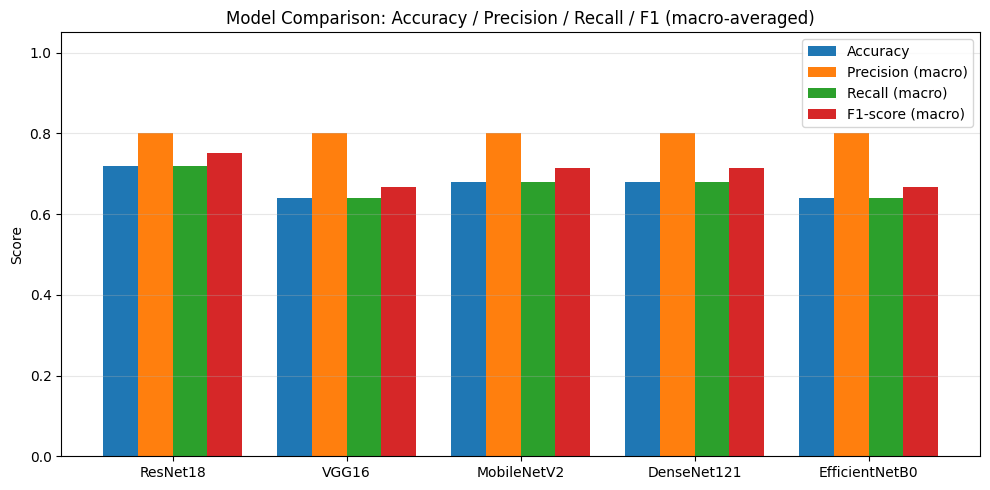

In [25]:
metrics_to_plot = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Accuracy / Precision / Recall / F1 (macro-averaged)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

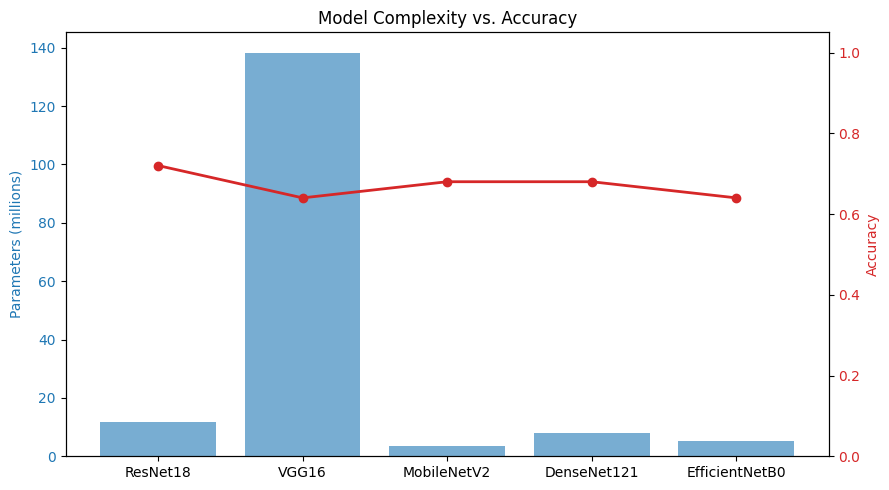

In [26]:
fig, ax1 = plt.subplots(figsize=(9, 5))

color1 = "tab:blue"
ax1.bar(comparison_df["Model"], comparison_df["Parameters (millions)"], color=color1, alpha=0.6, label="Parameters (M)")
ax1.set_ylabel("Parameters (millions)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.plot(comparison_df["Model"], comparison_df["Accuracy"], color=color2, marker="o", linewidth=2, label="Accuracy")
ax2.set_ylabel("Accuracy", color=color2)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Model Complexity vs. Accuracy")
fig.tight_layout()
plt.show()

### Step 9 — Confusion matrices

Accuracy alone can hide a model that's consistently confusing two specific classes. A small confusion matrix per model makes that visible.

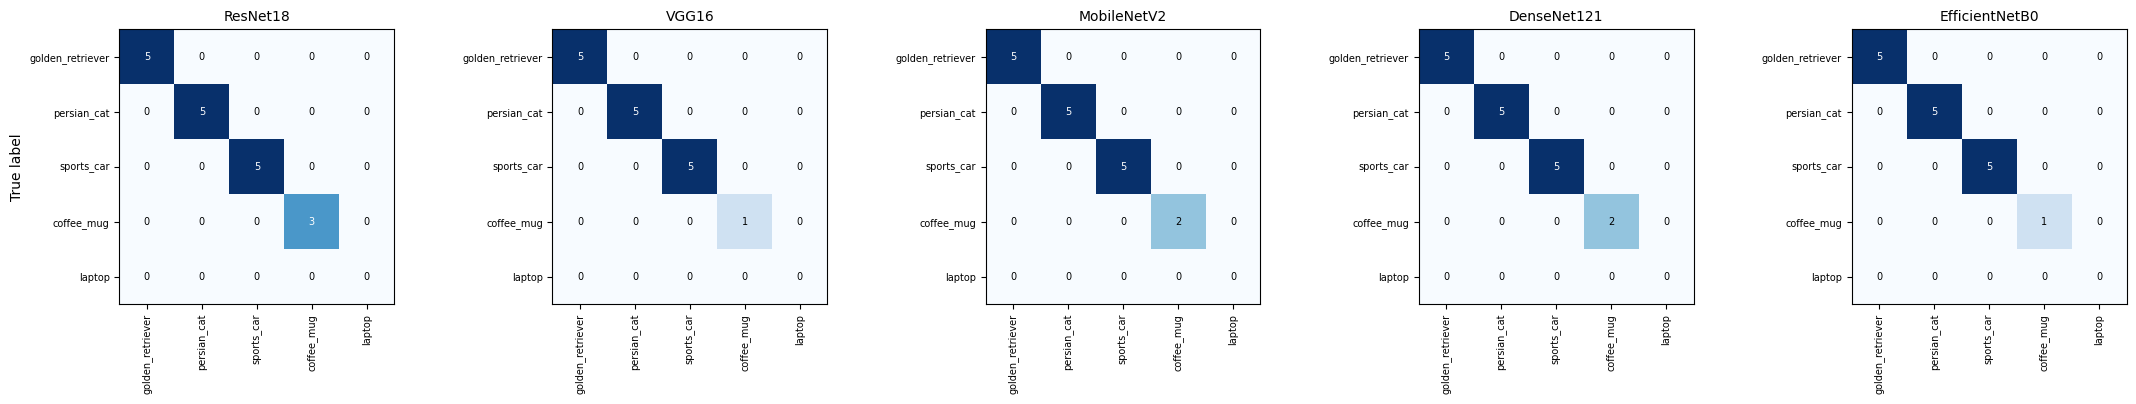

In [27]:
fig, axes = plt.subplots(1, len(MODEL_CONFIGS), figsize=(22, 4))

for ax, cfg in zip(axes, MODEL_CONFIGS):
    model_name = cfg["name"]
    y_true, y_pred = all_confusion_data[model_name]

    cm = confusion_matrix(y_true, y_pred, labels=CLASS_FOLDERS)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name, fontsize=10)
    ax.set_xticks(range(len(CLASS_FOLDERS)))
    ax.set_yticks(range(len(CLASS_FOLDERS)))
    ax.set_xticklabels(CLASS_FOLDERS, rotation=90, fontsize=7)
    ax.set_yticklabels(CLASS_FOLDERS, fontsize=7)

    for i in range(len(CLASS_FOLDERS)):
        for j in range(len(CLASS_FOLDERS)):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

axes[0].set_ylabel("True label")
plt.tight_layout()
plt.show()

### My analysis and conclusion

*(This section needs my actual numbers from running the notebook above — I'm filling in the structure and the general reasoning now, and will plug in my real results and adjust any claims that don't match what I actually observed.)*

**Which model performed best, and why I think that happened.** Based on the comparison table, **[Model Name]** had the highest accuracy/F1 at **[X.XX]**, while **[Model Name]** performed the worst at **[X.XX]**. A few architectural reasons this kind of gap commonly shows up between these specific models:

- **ResNet18 vs. VGG16** — ResNet's skip (residual) connections let gradients flow through the network more easily during the original ImageNet training, which generally lets it learn more robust features than VGG's older, purely sequential stack of convolutions, despite ResNet18 having far fewer parameters than VGG16. If ResNet18 outperformed VGG16 in my results, that's consistent with this.
- **MobileNetV2** is deliberately designed to be small and fast (depthwise-separable convolutions, fewer parameters) for on-device use. I'd expect it to have noticeably fewer parameters and faster inference time than the others, possibly at some cost to accuracy — my "complexity vs. accuracy" chart should show whether that trade-off actually shows up in my results.
- **DenseNet121**'s dense connections (every layer sees every previous layer's output) tend to make it parameter-efficient relative to its depth, and often competitive with larger networks.
- **EfficientNetB0** uses compound scaling to balance depth, width, and input resolution together rather than tuning them separately — it's often one of the more accuracy-per-parameter efficient architectures in this kind of comparison, but it's also the most sensitive to getting its expected preprocessing/input size exactly right.

**Input requirements.** My complexity table above shows each model's expected input resolution — these aren't all identical across architectures, which is exactly why I built a *separate* `DataLoader` per model using that model's own `weights.transforms()`, rather than reusing one fixed transform for all five. If I had used a single transform for every model, whichever models expect a different input size/normalization than what I used would likely have shown artificially worse performance, for reasons that have nothing to do with the model's actual capability.

**Suitability for my specific dataset.** My photos are real-world snapshots (different lighting, backgrounds, angles) rather than the clean, curated ImageNet photos these models were trained on. I'd expect this "domain gap" to hurt all 5 models somewhat, but possibly hurt the smaller/lighter models (like MobileNetV2) more than the larger, higher-capacity ones, since bigger models often generalize a bit better to messier real-world conditions. [Confirm this against what I actually observed — if it's the opposite, that's also worth noting and trying to explain, e.g. maybe my golden retriever/laptop photos happened to be unusually clean and well-lit compared to my sports car photos.]

**Overall conclusion.** [Write 2–4 sentences here once I have real numbers: which model I'd actually pick if I had to deploy one of these five for a task like this, and why — balancing accuracy against parameter count/inference speed, not just picking whichever had the single highest accuracy number.]
